# 🔶 BRONZE LAYER - Análise Exploratória Inicial

## Objetivo
Entender a qualidade e estrutura dos dados brutos de notificações de **Dengue** (SINAN).

### O que será analisado:
1. Exploração Inicial
2. Qualidade dos Dados
3. Análises Temporais
4. Análises Geográficas
5. Análises Demográficas
6. Análises Clínicas
7. Consistência dos Dados
8. Correlações Iniciais

---
## 📦 Importação de Bibliotecas

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

---
## 📂 Carregamento dos Dados

In [10]:
# Caminho do arquivo CSV bruto
DATA_PATH = '../Data_Layer/raw/data/DENGBR25.csv'

# Carregamento do dataset
df = pd.read_csv(DATA_PATH, encoding='latin-1', low_memory=False)

print(f"✅ Dataset carregado com sucesso!")

✅ Dataset carregado com sucesso!


---
## 1️⃣ Exploração Inicial
Visão geral da estrutura e conteúdo do dataset.

In [11]:
# Shape do dataset
print("="*60)
print("📊 DIMENSÕES DO DATASET")
print("="*60)
print(f"Número de linhas (notificações): {df.shape[0]:,}")
print(f"Número de colunas (variáveis): {df.shape[1]}")
print(f"Total de células: {df.shape[0] * df.shape[1]:,}")

📊 DIMENSÕES DO DATASET
Número de linhas (notificações): 1,668,787
Número de colunas (variáveis): 121
Total de células: 201,923,227


In [12]:
# Tipos de dados de cada coluna
print("="*60)
print("📋 TIPOS DE DADOS POR COLUNA")
print("="*60)
print(df.dtypes.value_counts())
print("\n")
print(df.dtypes)

📋 TIPOS DE DADOS POR COLUNA
float64    93
object     19
int64       9
Name: count, dtype: int64


TP_NOT          int64
ID_AGRAVO      object
DT_NOTIFIC     object
SEM_NOT         int64
NU_ANO          int64
               ...   
NDUPLIC_N     float64
DT_DIGITA      object
CS_FLXRET     float64
FLXRECEBI     float64
MIGRADO_W     float64
Length: 121, dtype: object


In [13]:
# Primeiras linhas do dataset
print("📌 Primeiras 5 linhas:")
df.head()

📌 Primeiras 5 linhas:


,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,SEM_PRI,ANO_NASC,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_PAIS,DT_INVEST,ID_OCUPA_N,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,DT_CHIK_S1,DT_CHIK_S2,DT_PRNT,RES_CHIKS1,RES_CHIKS2,RESUL_PRNT,DT_SORO,RESUL_SORO,DT_NS1,RESUL_NS1,DT_VIRAL,RESUL_VI_N,DT_PCR,RESUL_PCR_,SOROTIPO,HISTOPA_N,IMUNOH_N,HOSPITALIZ,DT_INTERNA,UF,MUNICIPIO,TPAUTOCTO,COUFINF,COPAISINF,COMUNINF,CLASSI_FIN,CRITERIO,DOENCA_TRA,CLINC_CHIK,EVOLUCAO,DT_OBITO,DT_ENCERRA,ALRM_HIPOT,ALRM_PLAQ,ALRM_VOM,ALRM_SANG,ALRM_HEMAT,ALRM_ABDOM,ALRM_LETAR,ALRM_HEPAT,ALRM_LIQ,DT_ALRM,GRAV_PULSO,GRAV_CONV,GRAV_ENCH,GRAV_INSUF,GRAV_TAQUI,GRAV_EXTRE,GRAV_HIPOT,GRAV_HEMAT,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,DT_GRAV,MANI_HEMOR,EPISTAXE,GENGIVO,METRO,PETEQUIAS,HEMATURA,SANGRAM,LACO_N,PLASMATICO,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,TP_SISTEMA,NDUPLIC_N,DT_DIGITA,CS_FLXRET,FLXRECEBI,MIGRADO_W
0,2,A90,2024-12-29,202501,2024,32,320070,32004.0,2485397.0,2024-12-29,202501,2003.0,4021,M,6.0,4.0,6.0,32,320070.0,32004.0,1,2024-12-29,10001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,4.0,NaN,4.0,NaN,4.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,10.0,2.0,NaN,NaN,NaN,NaN,2025-02-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-29,NaN,NaN,NaN
1,2,A90,2024-12-29,202501,2024,32,320020,32004.0,2448025.0,2024-12-29,202501,1952.0,4072,F,5.0,1.0,1.0,32,320020.0,32004.0,1,2024-12-29,999990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,4.0,NaN,4.0,NaN,4.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,10.0,2.0,NaN,NaN,1.0,NaN,2025-02-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-29,NaN,NaN,NaN
2,2,A90,2024-12-29,202501,2024,32,320020,32004.0,2448025.0,2024-12-29,202501,1951.0,4073,M,6.0,4.0,1.0,32,320020.0,32004.0,1,2024-12-29,999990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,4.0,NaN,4.0,NaN,4.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,10.0,2.0,NaN,NaN,1.0,NaN,2025-02-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-29,NaN,NaN,NaN
3,2,A90,2024-12-29,202501,2024,32,320020,32004.0,2448025.0,2024-12-29,202501,2013.0,4011,F,5.0,4.0,3.0,32,320020.0,32004.0,1,2024-12-29,999992,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,4.0,NaN,4.0,NaN,4.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,10.0,2.0,NaN,NaN,1.0,NaN,2025-02-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-29,NaN,NaN,NaN
4,2,A90,2024-12-29,202501,2024,32,320020,32004.0,2448025.0,2024-12-29,202501,1998.0,4026,M,6.0,1.0,5.0,32,320020.0,32004.0,1,2024-12-29,761240,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,4.0,NaN,4.0,NaN,4.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,10.0,2.0,NaN,NaN,1.0,NaN,2025-02-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-29,NaN,NaN,NaN


In [14]:
# Últimas linhas do dataset
print("📌 Últimas 5 linhas:")
df.tail()

📌 Últimas 5 linhas:


,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,SEM_PRI,ANO_NASC,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_PAIS,DT_INVEST,ID_OCUPA_N,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,DT_CHIK_S1,DT_CHIK_S2,DT_PRNT,RES_CHIKS1,RES_CHIKS2,RESUL_PRNT,DT_SORO,RESUL_SORO,DT_NS1,RESUL_NS1,DT_VIRAL,RESUL_VI_N,DT_PCR,RESUL_PCR_,SOROTIPO,HISTOPA_N,IMUNOH_N,HOSPITALIZ,DT_INTERNA,UF,MUNICIPIO,TPAUTOCTO,COUFINF,COPAISINF,COMUNINF,CLASSI_FIN,CRITERIO,DOENCA_TRA,CLINC_CHIK,EVOLUCAO,DT_OBITO,DT_ENCERRA,ALRM_HIPOT,ALRM_PLAQ,ALRM_VOM,ALRM_SANG,ALRM_HEMAT,ALRM_ABDOM,ALRM_LETAR,ALRM_HEPAT,ALRM_LIQ,DT_ALRM,GRAV_PULSO,GRAV_CONV,GRAV_ENCH,GRAV_INSUF,GRAV_TAQUI,GRAV_EXTRE,GRAV_HIPOT,GRAV_HEMAT,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,DT_GRAV,MANI_HEMOR,EPISTAXE,GENGIVO,METRO,PETEQUIAS,HEMATURA,SANGRAM,LACO_N,PLASMATICO,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,TP_SISTEMA,NDUPLIC_N,DT_DIGITA,CS_FLXRET,FLXRECEBI,MIGRADO_W
1668782,2,A90,2026-01-03,202553,2026,35,354980,1354.0,2797844.0,2026-01-02,202553,2006.0,4019,F,6.0,1.0,NaN,35,354980.0,1354.0,1,2026-01-03,NaN,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2026-01-03,0.0,NaN,NaN
1668783,2,A90,2026-01-03,202553,2026,35,352440,1351.0,2086492.0,2025-12-30,202553,1996.0,4029,M,6.0,1.0,6.0,35,352440.0,1351.0,1,2026-01-03,NaN,1.0,1.0,1.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,2026-01-03,2.0,NaN,4.0,NaN,4.0,NaN,4.0,4.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2026-01-03,0.0,NaN,NaN
1668784,2,A90,2026-01-03,202553,2026,35,355030,1331.0,9349898.0,2026-01-02,202553,1978.0,4047,M,6.0,1.0,7.0,35,355030.0,1331.0,1,2026-01-03,NaN,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-03,2.0,2026-01-03,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2026-01-03,0.0,NaN,NaN
1668785,2,A90,2026-01-03,202553,2026,35,354140,1346.0,6905102.0,2026-01-01,202553,1998.0,4027,M,6.0,1.0,8.0,35,354140.0,1346.0,1,2026-01-03,223605,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,4.0,NaN,4.0,NaN,4.0,NaN,4.0,4.0,2.0,NaN,NaN,NaN,1.0,35.0,1.0,354140.0,10.0,2.0,NaN,NaN,1.0,NaN,2026-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2026-01-03,0.0,NaN,NaN
1668786,2,A90,2026-01-03,202553,2026,35,354990,1351.0,26417.0,2025-12-26,202552,1997.0,4028,F,5.0,1.0,6.0,35,354990.0,1351.0,1,2026-01-03,NaN,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-03,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2026-01-03,0.0,NaN,NaN


In [15]:
# Resumo estatístico das variáveis numéricas
print("📈 Estatísticas descritivas:")
df.describe()

📈 Estatísticas descritivas:


,TP_NOT,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,SEM_PRI,ANO_NASC,NU_IDADE_N,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_PAIS,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,RES_CHIKS1,RES_CHIKS2,RESUL_PRNT,RESUL_SORO,RESUL_NS1,RESUL_VI_N,RESUL_PCR_,SOROTIPO,HISTOPA_N,IMUNOH_N,HOSPITALIZ,UF,MUNICIPIO,TPAUTOCTO,COUFINF,COPAISINF,COMUNINF,CLASSI_FIN,CRITERIO,DOENCA_TRA,CLINC_CHIK,EVOLUCAO,ALRM_HIPOT,ALRM_PLAQ,ALRM_VOM,ALRM_SANG,ALRM_HEMAT,ALRM_ABDOM,ALRM_LETAR,ALRM_HEPAT,ALRM_LIQ,GRAV_PULSO,GRAV_CONV,GRAV_ENCH,GRAV_INSUF,GRAV_TAQUI,GRAV_EXTRE,GRAV_HIPOT,GRAV_HEMAT,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,MANI_HEMOR,EPISTAXE,GENGIVO,METRO,PETEQUIAS,HEMATURA,SANGRAM,LACO_N,PLASMATICO,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,TP_SISTEMA,NDUPLIC_N,CS_FLXRET,FLXRECEBI,MIGRADO_W
count,1.668787e+06,1.668787e+06,1.668787e+06,1.668787e+06,1.668787e+06,1.618985e+06,1.668626e+06,1.668787e+06,1.664137e+06,1.668787e+06,1.668610e+06,1.668785e+06,1.357933e+06,1.668787e+06,1.668780e+06,1.618620e+06,1.668787e+06,1.568517e+06,1.568517e+06,1.568517e+06,1.568517e+06,1.568517e+06,1.568517e+06,1.568517e+06,1.568517e+06,1.568517e+06,1.568517e+06,1.568517e+06,1.568517e+06,1.568517e+06,1.568517e+06,1.568517e+06,1.568517e+06,1.568517e+06,1.568517e+06,1.568517e+06,1.568517e+06,1.568517e+06,3795.000000,3409.000000,3592.000000,956296.000000,1.085123e+06,789361.000000,826606.000000,48085.000000,682949.000000,683164.000000,1.274609e+06,67500.000000,66378.000000,1.199421e+06,1.118988e+06,1.118949e+06,1.115195e+06,1.623107e+06,1.468279e+06,0.0,5771.000000,1.398145e+06,38588.000000,38685.000000,38581.000000,38570.000000,38505.000000,38979.000000,38595.000000,38490.000000,38489.000000,3094.000000,3085.000000,3085.000000,3083.000000,3088.000000,3078.000000,3082.000000,3086.000000,3084.000000,3079.000000,3076.000000,3073.000000,3075.000000,3081.000000,3074.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1615291.0,4801.0,1.633795e+06,1.0,0.0
mean,2.000001e+00,2.025164e+05,2.024999e+03,3.599912e+01,3.624453e+05,2.121368e+03,4.082011e+06,2.025158e+05,1.988310e+03,4.024721e+03,5.799316e+00,3.106500e+00,6.997032e+00,3.598681e+01,3.623127e+05,2.121493e+03,1.000106e+00,1.137893e+00,1.193116e+00,1.194569e+00,1.916046e+00,1.730876e+00,1.562935e+00,1.709754e+00,1.968561e+00,1.901751e+00,1.829568e+00,1.946451e+00,1.955557e+00,1.973353e+00,1.690775e+00,1.951684e+00,1.994753e+00,1.995111e+00,1.994968e+00,1.896358e+00,1.995419e+00,1.993143e+00,3.377602,3.882664,3.770601,3.242246,2.671825e+00,3.976508,3.799541,2.018259,3.994751,3.993829,2.097086e+00,35.716933,359550.551749,1.080452e+00,3.635455e+01,1.003203e+00,3.661626e+05,9.809175e+00,1.678400e+00,NaN,1.005025,1.231448e+00,1.836866,1.435957,1.837563,1.790640,1.943851,1.553657,1.888068,1.982593,1.956585,1.837104,1.892707,1.817828,1.808304,1.703692,1.727420,1.783907,1.855152,1.857004,1.941215,1.973342,1.940449,1.979837,1.700422,1.849382,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,3.080980e-01,2.0,NaN
std,7.741044e-04,1.103341e+01,4.501199e-02,7.138655e+00,7.105269e+04,4.457667e+03,2.620853e+06,1.092891e+01,2.001461e+01,1.314940e+02,1.036076e+00,2.673098e+00,2.498733e+00,7.148306e+00,7.114836e+04,4.456004e+03,1.104802e-01,3.447881e-01,3.947435e-01,3.958688e-01,2.773196e-01,4.435045e-01,4.960235e-01,4.538760e-01,1.745000e-01,2.976509e-01,3.760123e-01,2.251249e-01,2.060764e-01,1.610490e-01,4.621743e-01,2.144339e-01,7.224588e-02,6.974810e-02,7.075444e-02,3.047963e-01,6.753082e-02,8.252523e-02,1.140834,0.499726,0.746471,1.258285,1.391507e+00,0.255918,0.729987,0.512346,0.105353,0.110489,1.061379e+00,8.191837,81515.657717,3.678577e-01,6.672833e+00,7.883053e-01,6.626153e+04,6.497207e-01,5.071224e-01,NaN,0.070716,1.335278e+00,0.369492,0.495888,0.368856,0.406857,0.230211,0.497119,0.315286,0.130784,0.203792,0.369

---
## 2️⃣ Qualidade dos Dados
Análise de valores nulos, duplicatas e completude.

In [16]:
# Percentual de valores nulos por coluna
null_analysis = pd.DataFrame({
    'Coluna': df.columns,
    'Nulos': df.isnull().sum().values,
    '% Nulos': (df.isnull().sum().values / len(df) * 100).round(2)
}).sort_values('% Nulos', ascending=False).reset_index(drop=True)

print("="*60)
print("🔍 ANÁLISE DE VALORES NULOS")
print("="*60)
print(f"Total de células com valores nulos: {df.isnull().sum().sum():,}")
print(f"Percentual geral de nulos: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%")
print("\n")
null_analysis

🔍 ANÁLISE DE VALORES NULOS
Total de células com valores nulos: 108,828,345
Percentual geral de nulos: 53.90%




,Coluna,Nulos,% Nulos
0,DT_CHIK_S2,1668782,100.0
1,PLAQ_MENOR,1668787,100.0
2,EVIDENCIA,1668787,100.0
3,PLASMATICO,1668787,100.0
4,METRO,1668787,100.0
...,...,...,...
116,NU_IDADE_N,0,0.0
117,SG_UF,0,0.0
118,ID_PAIS,0,0.0
119,ID_MN_RESI,7,0.0


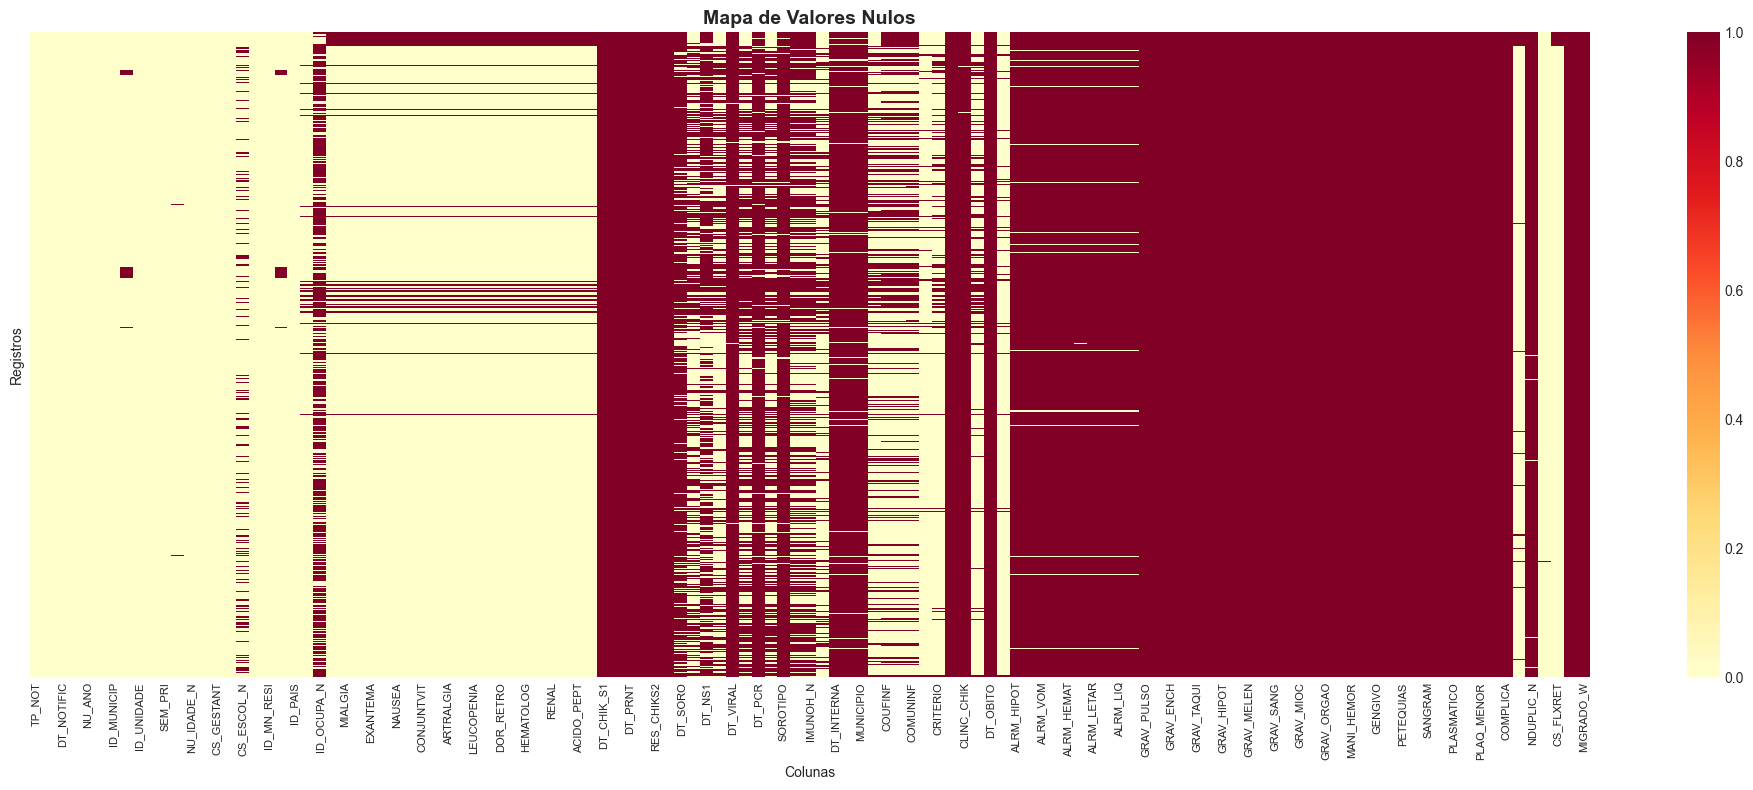

In [17]:
# Visualização de valores nulos (heatmap)
fig, ax = plt.subplots(figsize=(20, 8))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd')
plt.title('Mapa de Valores Nulos', fontsize=14, fontweight='bold')
plt.xlabel('Colunas')
plt.ylabel('Registros')
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

In [18]:
# Colunas com mais de 70% de valores nulos (candidatas a exclusão)
colunas_excluir = null_analysis[null_analysis['% Nulos'] > 70]['Coluna'].tolist()

print("="*60)
print("⚠️ COLUNAS COM >70% NULOS (Candidatas a Exclusão)")
print("="*60)
print(f"Total: {len(colunas_excluir)} colunas\n")
for col in colunas_excluir:
    pct = null_analysis[null_analysis['Coluna'] == col]['% Nulos'].values[0]
    print(f"  • {col}: {pct}%")

⚠️ COLUNAS COM >70% NULOS (Candidatas a Exclusão)
Total: 59 colunas

  • DT_CHIK_S2: 100.0%
  • PLAQ_MENOR: 100.0%
  • EVIDENCIA: 100.0%
  • PLASMATICO: 100.0%
  • METRO: 100.0%
  • SANGRAM: 100.0%
  • HEMATURA: 100.0%
  • PETEQUIAS: 100.0%
  • DOENCA_TRA: 100.0%
  • GENGIVO: 100.0%
  • MANI_HEMOR: 100.0%
  • EPISTAXE: 100.0%
  • LACO_N: 100.0%
  • MIGRADO_W: 100.0%
  • FLXRECEBI: 100.0%
  • COMPLICA: 100.0%
  • CON_FHD: 100.0%
  • DT_PRNT: 99.98%
  • DT_CHIK_S1: 99.93%
  • DT_OBITO: 99.85%
  • DT_GRAV: 99.83%
  • GRAV_ENCH: 99.82%
  • GRAV_CONV: 99.82%
  • GRAV_INSUF: 99.82%
  • GRAV_MIOC: 99.82%
  • GRAV_EXTRE: 99.82%
  • GRAV_HEMAT: 99.82%
  • GRAV_CONSC: 99.82%
  • GRAV_AST: 99.82%
  • GRAV_METRO: 99.82%
  • GRAV_MELEN: 99.82%
  • GRAV_SANG: 99.82%
  • GRAV_ORGAO: 99.82%
  • GRAV_HIPOT: 99.82%
  • GRAV_PULSO: 99.81%
  • GRAV_TAQUI: 99.81%
  • RES_CHIKS2: 99.8%
  • RESUL_PRNT: 99.78%
  • RES_CHIKS1: 99.77%
  • NDUPLIC_N: 99.71%
  • CLINC_CHIK: 99.65%
  • DT_VIRAL: 99.49%
  • DT_ALRM

In [19]:
# Análise de duplicatas
print("="*60)
print("🔄 ANÁLISE DE DUPLICATAS")
print("="*60)

duplicatas_totais = df.duplicated().sum()
print(f"Registros duplicados (todas as colunas): {duplicatas_totais:,}")
print(f"Percentual de duplicatas: {(duplicatas_totais / len(df) * 100):.2f}%")

# Verificar campo NDUPLIC_N se existir
if 'NDUPLIC_N' in df.columns:
    print(f"\nValores únicos em NDUPLIC_N: {df['NDUPLIC_N'].nunique()}")
    print(df['NDUPLIC_N'].value_counts())

🔄 ANÁLISE DE DUPLICATAS
Registros duplicados (todas as colunas): 719
Percentual de duplicatas: 0.04%

Valores únicos em NDUPLIC_N: 1
NDUPLIC_N
1.0    4801
Name: count, dtype: int64


In [20]:
# Valores únicos em colunas categóricas principais
colunas_categoricas = ['CS_SEXO', 'CS_RACA', 'CS_GESTANT', 'CS_ESCOL_N', 'SG_UF_NOT', 
                       'CLASSI_FIN', 'CRITERIO', 'EVOLUCAO', 'HOSPITALIZ']

print("="*60)
print("📊 VALORES ÚNICOS EM VARIÁVEIS CATEGÓRICAS")
print("="*60)

for col in colunas_categoricas:
    if col in df.columns:
        print(f"\n🔹 {col}:")
        print(df[col].value_counts(dropna=False))

📊 VALORES ÚNICOS EM VARIÁVEIS CATEGÓRICAS

🔹 CS_SEXO:
CS_SEXO
F      905577
M      761971
I        1238
NaN         1
Name: count, dtype: int64

🔹 CS_RACA:
CS_RACA
1.0    811466
4.0    528693
9.0    224297
2.0     80510
3.0     20473
5.0      3346
NaN         2
Name: count, dtype: int64

🔹 CS_GESTANT:
CS_GESTANT
6.0    913450
5.0    627259
9.0    114310
2.0      4279
1.0      3774
3.0      3472
4.0      2066
NaN       177
Name: count, dtype: int64

🔹 CS_ESCOL_N:
CS_ESCOL_N
9.0     520033
NaN     310854
6.0     303994
10.0    110437
8.0      89931
3.0      82955
5.0      81942
4.0      58574
1.0      49145
2.0      30628
7.0      24307
0.0       5987
Name: count, dtype: int64

🔹 SG_UF_NOT:
SG_UF_NOT
35    904577
31    167580
41    111683
52    102973
43     85812
51     35395
32     35053
29     32507
33     29422
42     27087
26     22982
15     17606
50     13942
53     11641
24      9692
22      9173
12      9149
27      8012
25      7762
23      5983
21      5402
13      5154
17    

---
## 3️⃣ Análises Temporais
Distribuição temporal das notificações.

In [21]:
# Converter colunas de data
colunas_data = ['DT_NOTIFIC', 'DT_SIN_PRI', 'DT_INVEST', 'DT_INTERNA', 'DT_OBITO', 'DT_ENCERRA']

for col in colunas_data:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

print("✅ Colunas de data convertidas!")

✅ Colunas de data convertidas!


In [22]:
# Range de datas do dataset
print("="*60)
print("📅 PERÍODO COBERTO PELO DATASET")
print("="*60)

if 'DT_NOTIFIC' in df.columns:
    print(f"Data mínima de notificação: {df['DT_NOTIFIC'].min()}")
    print(f"Data máxima de notificação: {df['DT_NOTIFIC'].max()}")
    print(f"Período total: {(df['DT_NOTIFIC'].max() - df['DT_NOTIFIC'].min()).days} dias")

if 'NU_ANO' in df.columns:
    print(f"\nAnos presentes: {sorted(df['NU_ANO'].dropna().unique())}")

📅 PERÍODO COBERTO PELO DATASET
Data mínima de notificação: 2024-12-29 00:00:00
Data máxima de notificação: 2026-01-05 00:00:00
Período total: 372 dias

Anos presentes: [np.int64(2024), np.int64(2025), np.int64(2026)]


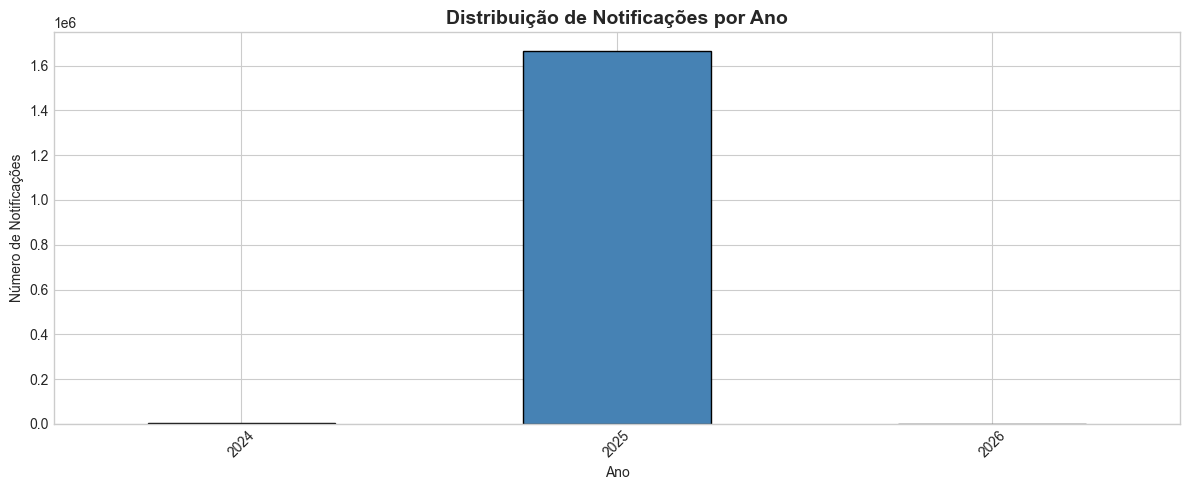

In [23]:
# Distribuição de notificações por ano
if 'NU_ANO' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    df['NU_ANO'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title('Distribuição de Notificações por Ano', fontsize=14, fontweight='bold')
    plt.xlabel('Ano')
    plt.ylabel('Número de Notificações')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

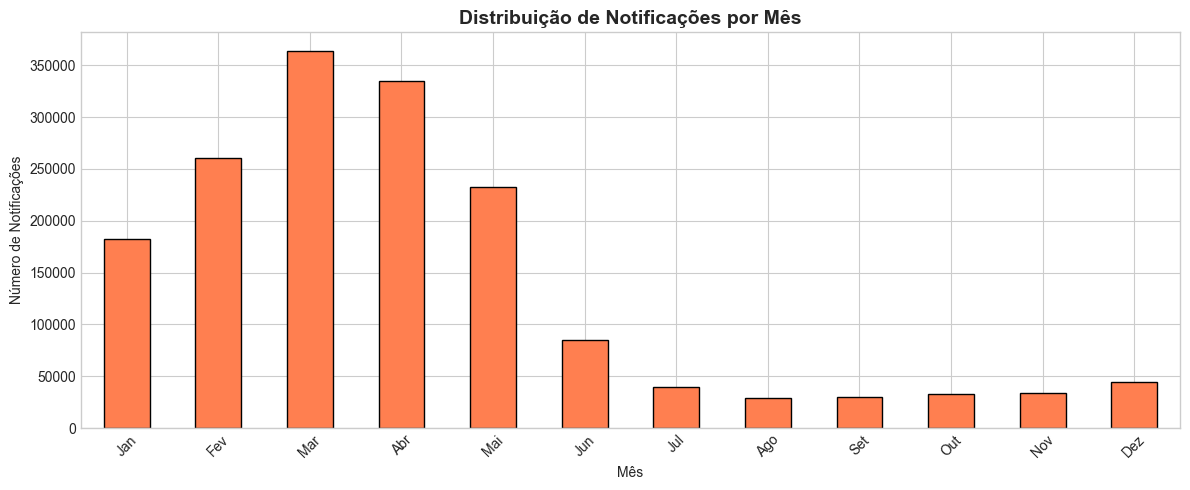

In [24]:
# Distribuição por mês (se houver dados suficientes)
if 'DT_NOTIFIC' in df.columns:
    df['MES_NOTIFIC'] = df['DT_NOTIFIC'].dt.month
    
    fig, ax = plt.subplots(figsize=(12, 5))
    df['MES_NOTIFIC'].value_counts().sort_index().plot(kind='bar', color='coral', edgecolor='black')
    plt.title('Distribuição de Notificações por Mês', fontsize=14, fontweight='bold')
    plt.xlabel('Mês')
    plt.ylabel('Número de Notificações')
    plt.xticks(ticks=range(12), labels=['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 
                                         'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'], rotation=45)
    plt.tight_layout()
    plt.show()

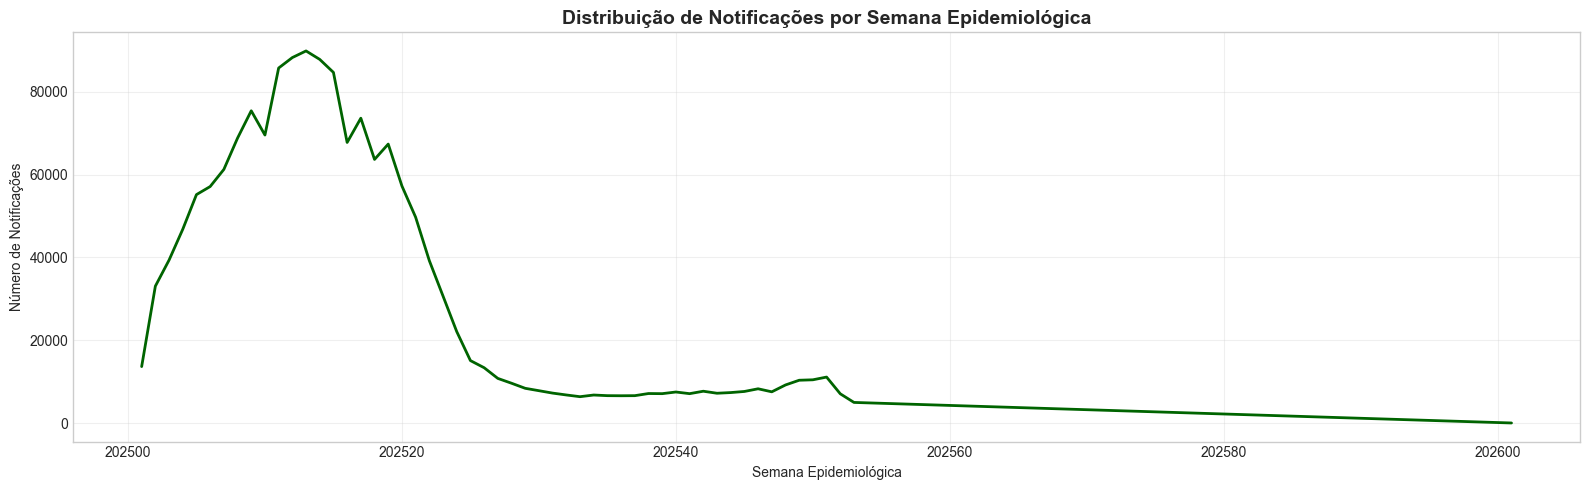

In [25]:
# Distribuição por semana epidemiológica
if 'SEM_NOT' in df.columns:
    fig, ax = plt.subplots(figsize=(16, 5))
    df['SEM_NOT'].value_counts().sort_index().plot(kind='line', color='darkgreen', linewidth=2)
    plt.title('Distribuição de Notificações por Semana Epidemiológica', fontsize=14, fontweight='bold')
    plt.xlabel('Semana Epidemiológica')
    plt.ylabel('Número de Notificações')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

⏱️ TEMPO ENTRE SINTOMAS E NOTIFICAÇÃO (dias)
count    1.668787e+06
mean     4.243337e+00
std      1.058214e+01
min      0.000000e+00
25%      1.000000e+00
50%      3.000000e+00
75%      4.000000e+00
max      3.670000e+02
Name: TEMPO_SINTOMAS_NOTIFIC, dtype: float64


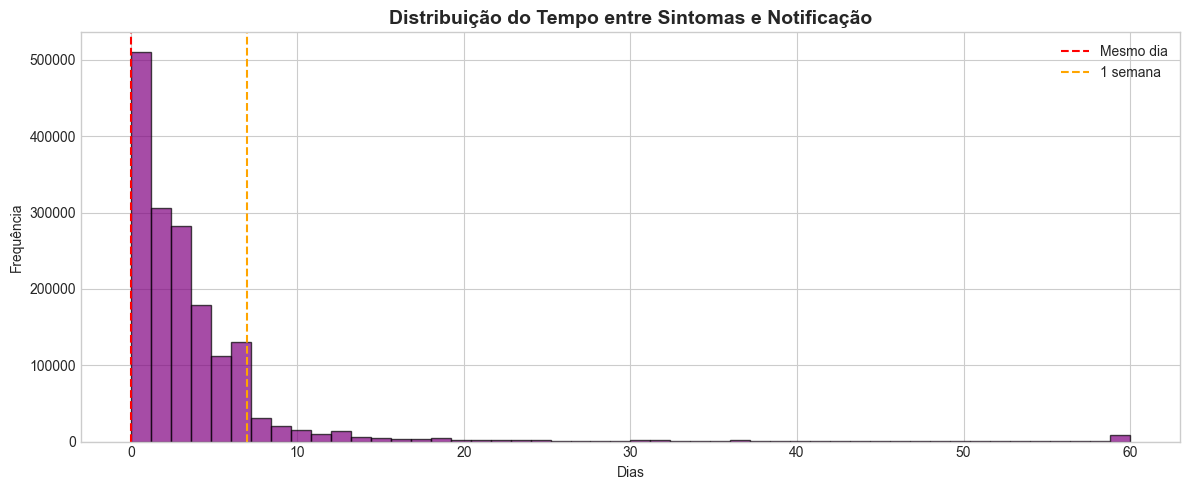

In [26]:
# Tempo entre sintomas e notificação (indicador de qualidade da vigilância)
if 'DT_NOTIFIC' in df.columns and 'DT_SIN_PRI' in df.columns:
    df['TEMPO_SINTOMAS_NOTIFIC'] = (df['DT_NOTIFIC'] - df['DT_SIN_PRI']).dt.days
    
    print("="*60)
    print("⏱️ TEMPO ENTRE SINTOMAS E NOTIFICAÇÃO (dias)")
    print("="*60)
    print(df['TEMPO_SINTOMAS_NOTIFIC'].describe())
    
    # Histograma
    fig, ax = plt.subplots(figsize=(12, 5))
    df['TEMPO_SINTOMAS_NOTIFIC'].dropna().clip(lower=-10, upper=60).hist(bins=50, color='purple', edgecolor='black', alpha=0.7)
    plt.title('Distribuição do Tempo entre Sintomas e Notificação', fontsize=14, fontweight='bold')
    plt.xlabel('Dias')
    plt.ylabel('Frequência')
    plt.axvline(x=0, color='red', linestyle='--', label='Mesmo dia')
    plt.axvline(x=7, color='orange', linestyle='--', label='1 semana')
    plt.legend()
    plt.tight_layout()
    plt.show()

---
## 4️⃣ Análises Geográficas
Distribuição espacial das notificações.

In [27]:
# Análise por UF
print("="*60)
print("🗺️ ANÁLISE GEOGRÁFICA")
print("="*60)

if 'SG_UF_NOT' in df.columns:
    print(f"Número de UFs presentes: {df['SG_UF_NOT'].nunique()}")
    print(f"\nDistribuição por UF:")
    print(df['SG_UF_NOT'].value_counts())

🗺️ ANÁLISE GEOGRÁFICA
Número de UFs presentes: 27

Distribuição por UF:
SG_UF_NOT
35    904577
31    167580
41    111683
52    102973
43     85812
51     35395
32     35053
29     32507
33     29422
42     27087
26     22982
15     17606
50     13942
53     11641
24      9692
22      9173
12      9149
27      8012
25      7762
23      5983
21      5402
13      5154
17      3631
16      2474
11      2329
28      1291
14       475
Name: count, dtype: int64


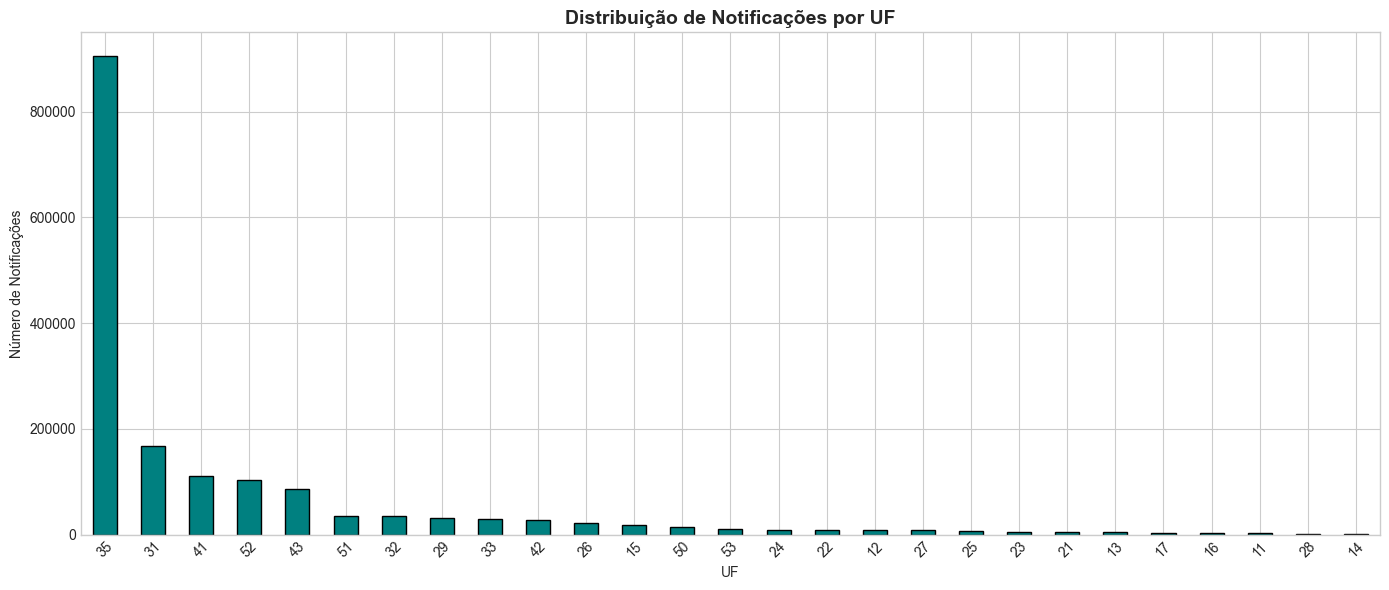

In [28]:
# Gráfico de barras por UF
if 'SG_UF_NOT' in df.columns:
    fig, ax = plt.subplots(figsize=(14, 6))
    df['SG_UF_NOT'].value_counts().head(27).plot(kind='bar', color='teal', edgecolor='black')
    plt.title('Distribuição de Notificações por UF', fontsize=14, fontweight='bold')
    plt.xlabel('UF')
    plt.ylabel('Número de Notificações')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [29]:
# Municípios únicos
if 'ID_MUNICIP' in df.columns:
    print(f"Número de municípios únicos: {df['ID_MUNICIP'].nunique()}")

if 'ID_MN_RESI' in df.columns:
    print(f"Número de municípios de residência únicos: {df['ID_MN_RESI'].nunique()}")

Número de municípios únicos: 4840
Número de municípios de residência únicos: 5187


🏙️ TOP 10 MUNICÍPIOS COM MAIS NOTIFICAÇÕES
ID_MUNICIP
355030    72837
354980    62356
431490    55608
350950    50753
520870    32835
354140    31549
317020    27142
353070    25716
354340    23977
354890    20755
Name: count, dtype: int64


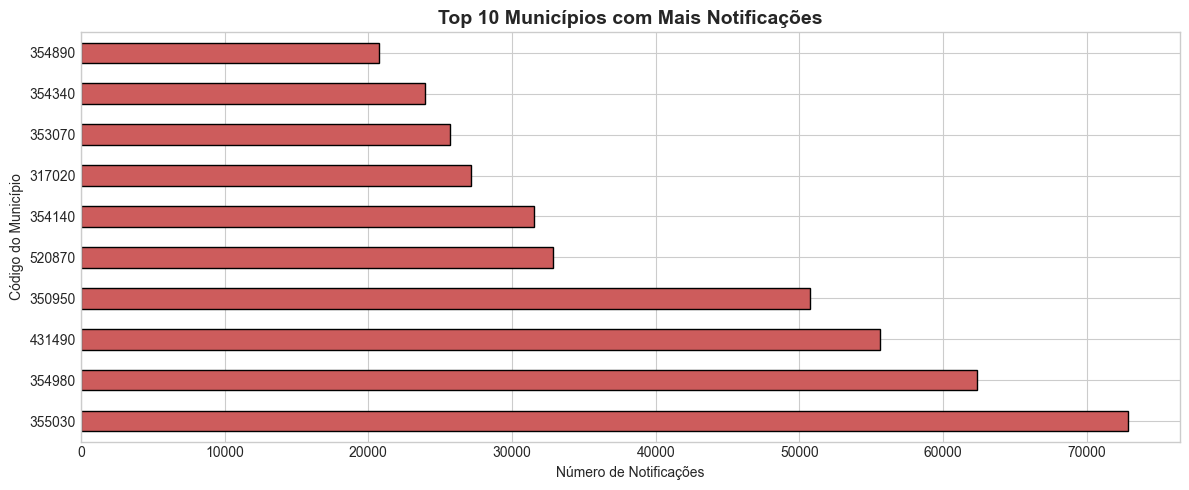

In [30]:
# Top 10 municípios com mais notificações
if 'ID_MUNICIP' in df.columns:
    print("="*60)
    print("🏙️ TOP 10 MUNICÍPIOS COM MAIS NOTIFICAÇÕES")
    print("="*60)
    top_municipios = df['ID_MUNICIP'].value_counts().head(10)
    print(top_municipios)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    top_municipios.plot(kind='barh', color='indianred', edgecolor='black')
    plt.title('Top 10 Municípios com Mais Notificações', fontsize=14, fontweight='bold')
    plt.xlabel('Número de Notificações')
    plt.ylabel('Código do Município')
    plt.tight_layout()
    plt.show()

In [31]:
# Análise de autoctonia
if 'TPAUTOCTO' in df.columns:
    print("="*60)
    print("📍 CLASSIFICAÇÃO DE AUTOCTONIA")
    print("="*60)
    print(df['TPAUTOCTO'].value_counts(dropna=False))

📍 CLASSIFICAÇÃO DE AUTOCTONIA
TPAUTOCTO
1.0    1139711
NaN     469366
3.0      36786
2.0      22924
Name: count, dtype: int64


---
## 5️⃣ Análises Demográficas
Perfil dos pacientes notificados.

In [32]:
# Distribuição de idade
print("="*60)
print("👤 ANÁLISE DEMOGRÁFICA")
print("="*60)

if 'NU_IDADE_N' in df.columns:
    print("\n📊 Estatísticas de Idade:")
    print(df['NU_IDADE_N'].describe())

👤 ANÁLISE DEMOGRÁFICA

📊 Estatísticas de Idade:
count    1.668787e+06
mean     4.024721e+03
std      1.314940e+02
min      0.000000e+00
25%      4.020000e+03
50%      4.034000e+03
75%      4.050000e+03
max      4.407000e+03
Name: NU_IDADE_N, dtype: float64


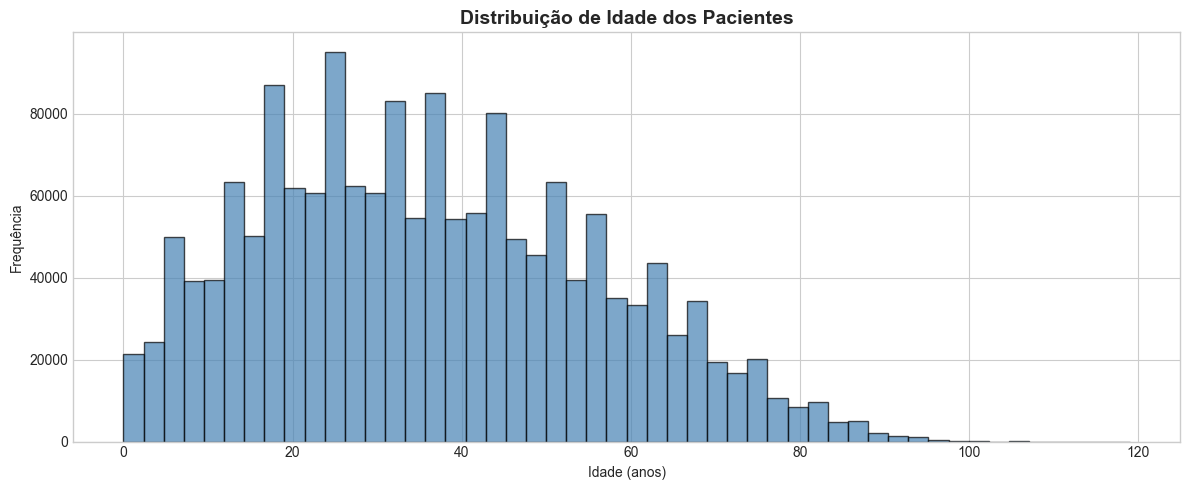

In [33]:
# Histograma de idade
if 'NU_IDADE_N' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    # Filtrar idades válidas (considerando código SINAN: 4XXX = anos)
    idades_validas = df['NU_IDADE_N'][(df['NU_IDADE_N'] >= 4000) & (df['NU_IDADE_N'] < 4120)]
    idades_anos = idades_validas - 4000  # Converter para anos
    
    idades_anos.hist(bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    plt.title('Distribuição de Idade dos Pacientes', fontsize=14, fontweight='bold')
    plt.xlabel('Idade (anos)')
    plt.ylabel('Frequência')
    plt.tight_layout()
    plt.show()


👫 Distribuição por Sexo:
CS_SEXO
F      905577
M      761971
I        1238
NaN         1
Name: count, dtype: int64


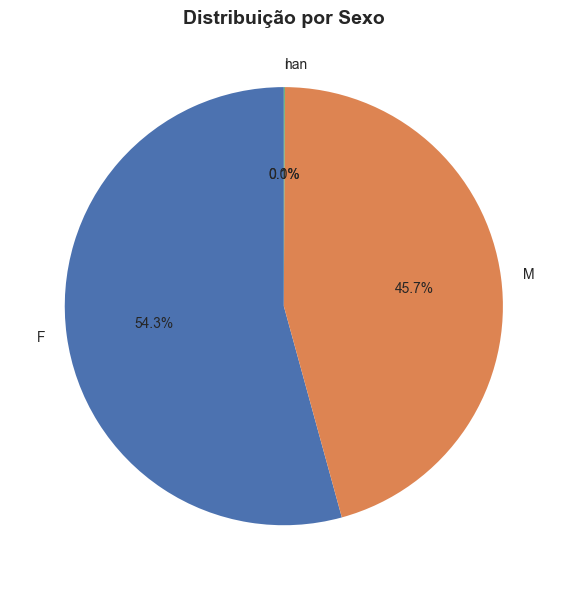

In [34]:
# Distribuição por sexo
if 'CS_SEXO' in df.columns:
    print("\n👫 Distribuição por Sexo:")
    sexo_counts = df['CS_SEXO'].value_counts(dropna=False)
    print(sexo_counts)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ['#4C72B0', '#DD8452', '#55A868']
    sexo_counts.plot(kind='pie', autopct='%1.1f%%', colors=colors, startangle=90)
    plt.title('Distribuição por Sexo', fontsize=14, fontweight='bold')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()


🎨 Distribuição por Raça/Cor:
CS_RACA_LABEL
Branca      811466
Parda       528693
Ignorado    224297
Preta        80510
Amarela      20473
Indígena      3346
NaN              2
Name: count, dtype: int64


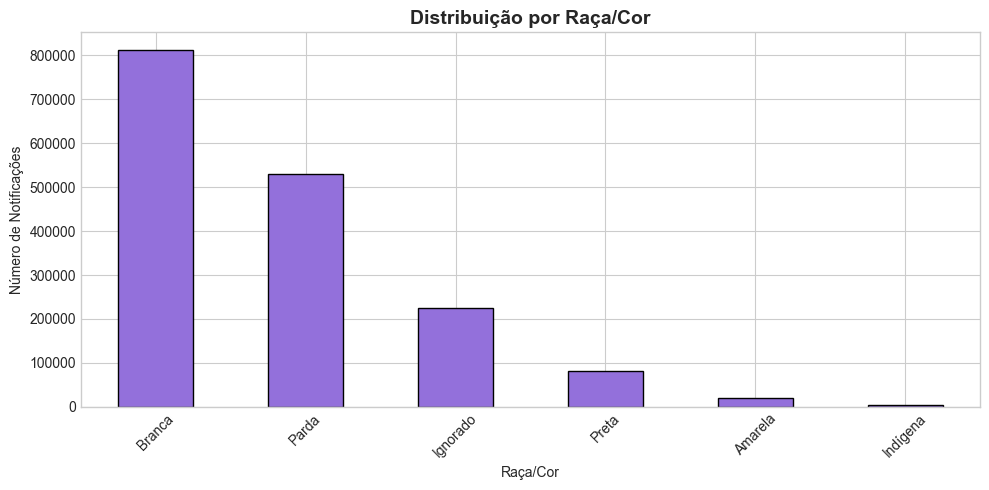

In [35]:
# Distribuição por raça/cor
if 'CS_RACA' in df.columns:
    print("\n🎨 Distribuição por Raça/Cor:")
    # Mapeamento de códigos SINAN
    raca_map = {1: 'Branca', 2: 'Preta', 3: 'Amarela', 4: 'Parda', 5: 'Indígena', 9: 'Ignorado'}
    df['CS_RACA_LABEL'] = df['CS_RACA'].map(raca_map)
    print(df['CS_RACA_LABEL'].value_counts(dropna=False))
    
    fig, ax = plt.subplots(figsize=(10, 5))
    df['CS_RACA_LABEL'].value_counts().plot(kind='bar', color='mediumpurple', edgecolor='black')
    plt.title('Distribuição por Raça/Cor', fontsize=14, fontweight='bold')
    plt.xlabel('Raça/Cor')
    plt.ylabel('Número de Notificações')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [36]:
# Análise de gestantes
if 'CS_GESTANT' in df.columns:
    print("\n🤰 Distribuição de Gestantes:")
    gestante_map = {1: '1º Trimestre', 2: '2º Trimestre', 3: '3º Trimestre', 
                    4: 'Idade gestacional ignorada', 5: 'Não', 6: 'Não se aplica', 9: 'Ignorado'}
    df['CS_GESTANT_LABEL'] = df['CS_GESTANT'].map(gestante_map)
    print(df['CS_GESTANT_LABEL'].value_counts(dropna=False))


🤰 Distribuição de Gestantes:
CS_GESTANT_LABEL
Não se aplica                 913450
Não                           627259
Ignorado                      114310
2º Trimestre                    4279
1º Trimestre                    3774
3º Trimestre                    3472
Idade gestacional ignorada      2066
NaN                              177
Name: count, dtype: int64


In [37]:
# Distribuição por escolaridade
if 'CS_ESCOL_N' in df.columns:
    print("\n📚 Distribuição por Escolaridade:")
    escol_map = {
        0: 'Analfabeto', 1: '1ª a 4ª série incompleta', 2: '4ª série completa',
        3: '5ª a 8ª série incompleta', 4: 'Ensino fundamental completo',
        5: 'Ensino médio incompleto', 6: 'Ensino médio completo',
        7: 'Educação superior incompleta', 8: 'Educação superior completa',
        9: 'Ignorado', 10: 'Não se aplica'
    }
    df['CS_ESCOL_LABEL'] = df['CS_ESCOL_N'].map(escol_map)
    print(df['CS_ESCOL_LABEL'].value_counts(dropna=False))


📚 Distribuição por Escolaridade:
CS_ESCOL_LABEL
Ignorado                        520033
NaN                             310854
Ensino médio completo           303994
Não se aplica                   110437
Educação superior completa       89931
5ª a 8ª série incompleta         82955
Ensino médio incompleto          81942
Ensino fundamental completo      58574
1ª a 4ª série incompleta         49145
4ª série completa                30628
Educação superior incompleta     24307
Analfabeto                        5987
Name: count, dtype: int64


---
## 6️⃣ Análises Clínicas
Sintomas, comorbidades, hospitalização e desfechos.

In [38]:
# Análise de sintomas
sintomas = ['FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA', 'VOMITO', 'NAUSEA', 
            'DOR_COSTAS', 'CONJUNTVIT', 'ARTRITE', 'ARTRALGIA', 'DOR_RETRO']

print("="*60)
print("🤒 ANÁLISE DE SINTOMAS")
print("="*60)

sintomas_presentes = []
for sintoma in sintomas:
    if sintoma in df.columns:
        # 1 = Sim, 2 = Não, 9 = Ignorado
        total = df[sintoma].notna().sum()
        sim = (df[sintoma] == 1).sum()
        pct = (sim / total * 100) if total > 0 else 0
        sintomas_presentes.append({'Sintoma': sintoma, 'Sim': sim, 'Total': total, '% Presente': round(pct, 2)})

df_sintomas = pd.DataFrame(sintomas_presentes).sort_values('% Presente', ascending=False)
print(df_sintomas)

🤒 ANÁLISE DE SINTOMAS
       Sintoma      Sim    Total  % Presente
0        FEBRE  1352229  1568517       86.21
1      MIALGIA  1265611  1568517       80.69
2     CEFALEIA  1263332  1568517       80.54
5       NAUSEA   685544  1568517       43.71
10   DOR_RETRO   485025  1568517       30.92
6   DOR_COSTAS   455256  1568517       29.02
4       VOMITO   422125  1568517       26.91
9    ARTRALGIA   267326  1568517       17.04
8      ARTRITE   154105  1568517        9.82
3     EXANTEMA   131684  1568517        8.40
7   CONJUNTVIT    49312  1568517        3.14


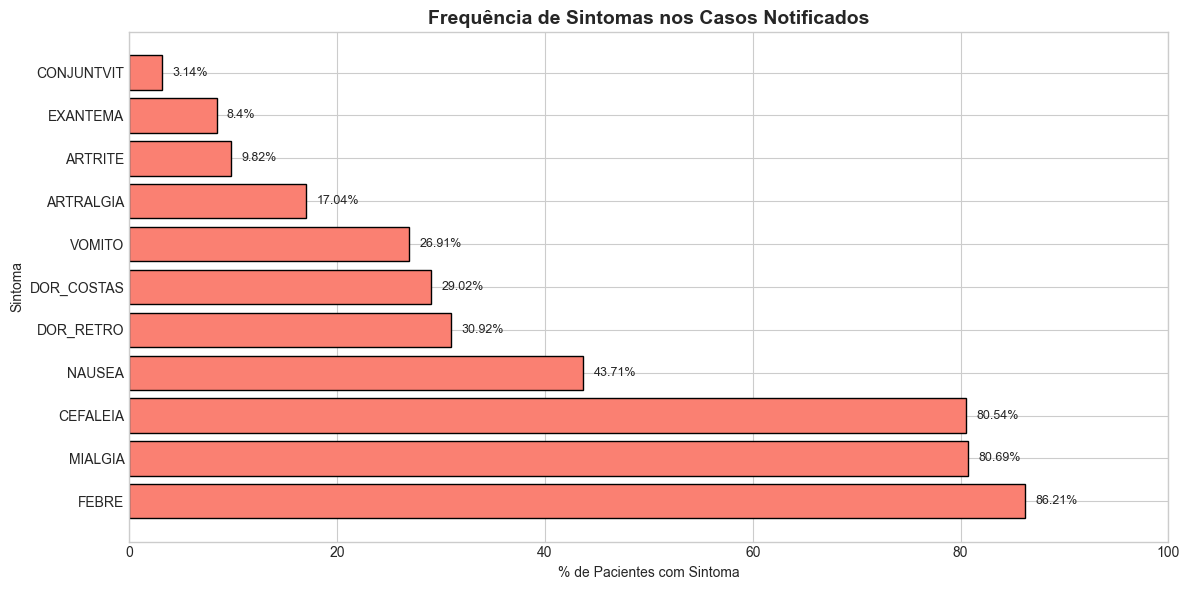

In [39]:
# Gráfico de sintomas
if len(df_sintomas) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = plt.barh(df_sintomas['Sintoma'], df_sintomas['% Presente'], color='salmon', edgecolor='black')
    plt.xlabel('% de Pacientes com Sintoma')
    plt.ylabel('Sintoma')
    plt.title('Frequência de Sintomas nos Casos Notificados', fontsize=14, fontweight='bold')
    plt.xlim(0, 100)
    
    # Adicionar valores nas barras
    for bar, val in zip(bars, df_sintomas['% Presente']):
        plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                 f'{val}%', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

In [40]:
# Análise de comorbidades
comorbidades = ['DIABETES', 'HEMATOLOG', 'HEPATOPAT', 'RENAL', 'HIPERTENSA', 'ACIDO_PEPT', 'AUTO_IMUNE']

print("="*60)
print("💊 ANÁLISE DE COMORBIDADES")
print("="*60)

comorb_presentes = []
for comorb in comorbidades:
    if comorb in df.columns:
        total = df[comorb].notna().sum()
        sim = (df[comorb] == 1).sum()
        pct = (sim / total * 100) if total > 0 else 0
        comorb_presentes.append({'Comorbidade': comorb, 'Sim': sim, 'Total': total, '% Presente': round(pct, 2)})

df_comorb = pd.DataFrame(comorb_presentes).sort_values('% Presente', ascending=False)
print(df_comorb)

💊 ANÁLISE DE COMORBIDADES
  Comorbidade     Sim    Total  % Presente
4  HIPERTENSA  162565  1568517       10.36
0    DIABETES   75785  1568517        4.83
6  AUTO_IMUNE   10756  1568517        0.69
1   HEMATOLOG    8230  1568517        0.52
3       RENAL    7892  1568517        0.50
2   HEPATOPAT    7668  1568517        0.49
5  ACIDO_PEPT    7186  1568517        0.46


In [41]:
# Hospitalização
if 'HOSPITALIZ' in df.columns:
    print("="*60)
    print("🏥 ANÁLISE DE HOSPITALIZAÇÃO")
    print("="*60)
    hosp_map = {1: 'Sim', 2: 'Não', 9: 'Ignorado'}
    df['HOSPITALIZ_LABEL'] = df['HOSPITALIZ'].map(hosp_map)
    print(df['HOSPITALIZ_LABEL'].value_counts(dropna=False))
    
    # Percentual de hospitalização
    total_validos = df[df['HOSPITALIZ'].isin([1, 2])].shape[0]
    hospitalizados = (df['HOSPITALIZ'] == 1).sum()
    pct_hosp = (hospitalizados / total_validos * 100) if total_validos > 0 else 0
    print(f"\n📊 Taxa de hospitalização: {pct_hosp:.2f}%")

🏥 ANÁLISE DE HOSPITALIZAÇÃO
HOSPITALIZ_LABEL
Não         1173836
NaN          394178
Sim           72708
Ignorado      28065
Name: count, dtype: int64

📊 Taxa de hospitalização: 5.83%


📋 CLASSIFICAÇÃO FINAL DOS CASOS
CLASSI_FIN_LABEL
Chikungunya            1411105
Inconclusivo            174789
NaN                      45680
Chikungunya crônico      34577
Zika                      2636
Name: count, dtype: int64


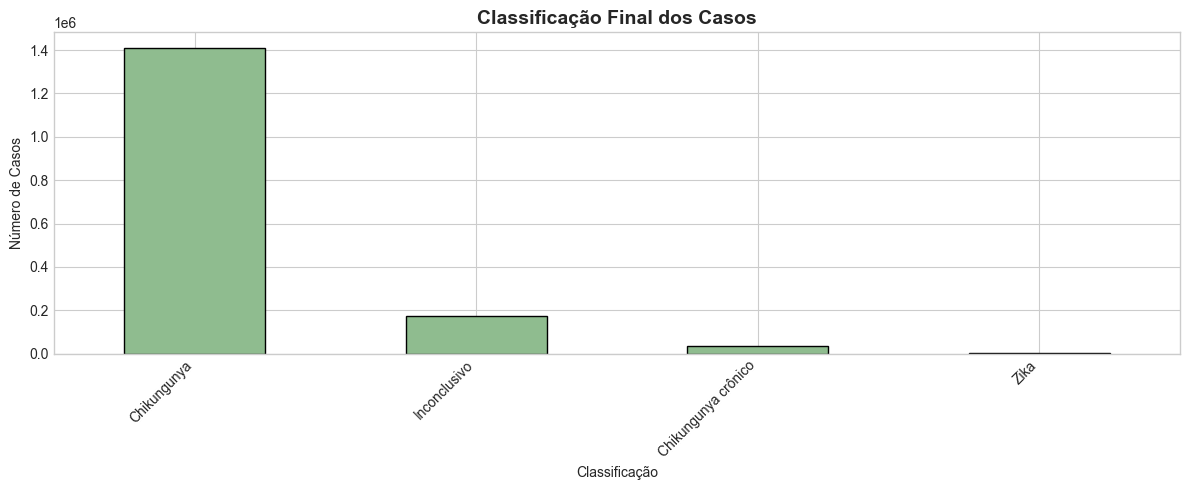

In [42]:
# Classificação final
if 'CLASSI_FIN' in df.columns:
    print("="*60)
    print("📋 CLASSIFICAÇÃO FINAL DOS CASOS")
    print("="*60)
    classi_map = {
        1: 'Dengue', 2: 'Dengue com sinais de alarme', 3: 'Dengue grave',
        5: 'Descartado', 8: 'Inconclusivo', 10: 'Chikungunya',
        11: 'Chikungunya crônico', 12: 'Zika', 13: 'Óbito em investigação'
    }
    df['CLASSI_FIN_LABEL'] = df['CLASSI_FIN'].map(classi_map)
    print(df['CLASSI_FIN_LABEL'].value_counts(dropna=False))
    
    fig, ax = plt.subplots(figsize=(12, 5))
    df['CLASSI_FIN_LABEL'].value_counts().plot(kind='bar', color='darkseagreen', edgecolor='black')
    plt.title('Classificação Final dos Casos', fontsize=14, fontweight='bold')
    plt.xlabel('Classificação')
    plt.ylabel('Número de Casos')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [43]:
# Evolução dos casos
if 'EVOLUCAO' in df.columns:
    print("="*60)
    print("📈 EVOLUÇÃO DOS CASOS")
    print("="*60)
    evolucao_map = {1: 'Cura', 2: 'Óbito pelo agravo', 3: 'Óbito por outras causas', 9: 'Ignorado'}
    df['EVOLUCAO_LABEL'] = df['EVOLUCAO'].map(evolucao_map)
    print(df['EVOLUCAO_LABEL'].value_counts(dropna=False))
    
    # Taxa de letalidade
    total_evolucao = df[df['EVOLUCAO'].isin([1, 2])].shape[0]
    obitos = (df['EVOLUCAO'] == 2).sum()
    taxa_letalidade = (obitos / total_evolucao * 100) if total_evolucao > 0 else 0
    print(f"\n⚠️ Taxa de letalidade: {taxa_letalidade:.4f}%")
    print(f"Total de óbitos pelo agravo: {obitos}")

📈 EVOLUÇÃO DOS CASOS
EVOLUCAO_LABEL
Cura                       1355666
NaN                         270839
Ignorado                     40036
Óbito pelo agravo             1773
Óbito por outras causas        473
Name: count, dtype: int64

⚠️ Taxa de letalidade: 0.1306%
Total de óbitos pelo agravo: 1773


In [44]:
# Critério de confirmação
if 'CRITERIO' in df.columns:
    print("="*60)
    print("🔬 CRITÉRIO DE CONFIRMAÇÃO")
    print("="*60)
    criterio_map = {1: 'Laboratorial', 2: 'Clínico-epidemiológico', 3: 'Em investigação'}
    df['CRITERIO_LABEL'] = df['CRITERIO'].map(criterio_map)
    print(df['CRITERIO_LABEL'].value_counts(dropna=False))

🔬 CRITÉRIO DE CONFIRMAÇÃO
CRITERIO_LABEL
Clínico-epidemiológico    938818
Laboratorial              500830
NaN                       200508
Em investigação            28631
Name: count, dtype: int64


---
## 7️⃣ Consistência dos Dados
Identificação de inconsistências e erros de preenchimento.

In [45]:
# Datas inválidas ou futuras
print("="*60)
print("⚠️ ANÁLISE DE CONSISTÊNCIA")
print("="*60)

data_atual = pd.Timestamp.now()

if 'DT_NOTIFIC' in df.columns:
    datas_futuras = (df['DT_NOTIFIC'] > data_atual).sum()
    print(f"\n📅 Datas de notificação futuras: {datas_futuras}")

if 'DT_SIN_PRI' in df.columns:
    datas_futuras_sin = (df['DT_SIN_PRI'] > data_atual).sum()
    print(f"📅 Datas de sintomas futuras: {datas_futuras_sin}")

⚠️ ANÁLISE DE CONSISTÊNCIA

📅 Datas de notificação futuras: 0
📅 Datas de sintomas futuras: 0


In [46]:
# Idades inconsistentes
if 'NU_IDADE_N' in df.columns:
    # Códigos SINAN: 4XXX = anos, 3XXX = meses, 2XXX = dias, 1XXX = horas
    idades_anos = df['NU_IDADE_N'][(df['NU_IDADE_N'] >= 4000) & (df['NU_IDADE_N'] < 5000)] - 4000
    idades_invalidas = idades_anos[idades_anos > 120].count()
    idades_negativas = idades_anos[idades_anos < 0].count()
    
    print(f"\n👤 Idades > 120 anos: {idades_invalidas}")
    print(f"👤 Idades negativas: {idades_negativas}")


👤 Idades > 120 anos: 39
👤 Idades negativas: 0


In [47]:
# Gestantes do sexo masculino (erro de preenchimento)
if 'CS_SEXO' in df.columns and 'CS_GESTANT' in df.columns:
    gestantes_masculino = df[(df['CS_SEXO'] == 'M') & (df['CS_GESTANT'].isin([1, 2, 3, 4]))].shape[0]
    print(f"\n🚨 Gestantes do sexo masculino (erro): {gestantes_masculino}")


🚨 Gestantes do sexo masculino (erro): 0


In [48]:
# Data de óbito sem evolução = óbito
if 'DT_OBITO' in df.columns and 'EVOLUCAO' in df.columns:
    obito_sem_evolucao = df[(df['DT_OBITO'].notna()) & (~df['EVOLUCAO'].isin([2, 3]))].shape[0]
    print(f"\n⚠️ Registros com data de óbito mas evolução ≠ óbito: {obito_sem_evolucao}")


⚠️ Registros com data de óbito mas evolução ≠ óbito: 199


In [49]:
# Data de sintomas posterior à notificação
if 'TEMPO_SINTOMAS_NOTIFIC' in df.columns:
    sintomas_depois_notific = (df['TEMPO_SINTOMAS_NOTIFIC'] < 0).sum()
    print(f"\n📅 Sintomas posteriores à notificação: {sintomas_depois_notific}")


📅 Sintomas posteriores à notificação: 0


In [50]:
# Resumo de inconsistências
print("\n" + "="*60)
print("📊 RESUMO DE INCONSISTÊNCIAS ENCONTRADAS")
print("="*60)

inconsistencias = {
    'Datas futuras': datas_futuras if 'datas_futuras' in dir() else 0,
    'Idades > 120 anos': idades_invalidas if 'idades_invalidas' in dir() else 0,
    'Gestantes masculinos': gestantes_masculino if 'gestantes_masculino' in dir() else 0,
    'Óbito sem evolução correspondente': obito_sem_evolucao if 'obito_sem_evolucao' in dir() else 0,
    'Sintomas após notificação': sintomas_depois_notific if 'sintomas_depois_notific' in dir() else 0
}

for tipo, qtd in inconsistencias.items():
    status = "✅" if qtd == 0 else "⚠️"
    print(f"{status} {tipo}: {qtd}")


📊 RESUMO DE INCONSISTÊNCIAS ENCONTRADAS
✅ Datas futuras: 0
⚠️ Idades > 120 anos: 39
✅ Gestantes masculinos: 0
⚠️ Óbito sem evolução correspondente: 199
✅ Sintomas após notificação: 0


---
## 8️⃣ Correlações Iniciais
Análise de relações entre variáveis.

🔗 CORRELAÇÕES ENTRE SINTOMAS


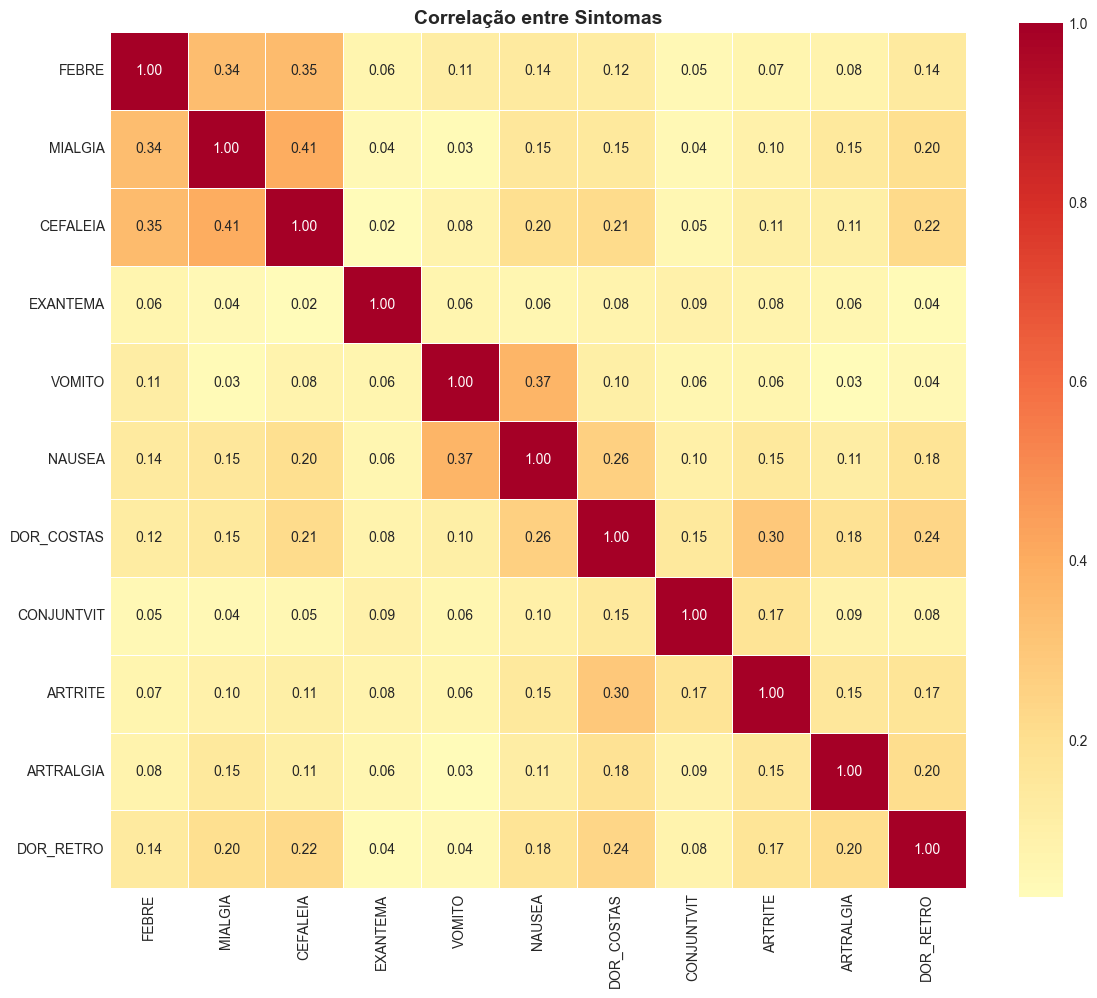

In [51]:
# Heatmap de correlação entre sintomas
print("="*60)
print("🔗 CORRELAÇÕES ENTRE SINTOMAS")
print("="*60)

sintomas_cols = [s for s in sintomas if s in df.columns]
df_sintomas_corr = df[sintomas_cols].copy()

# Converter para binário (1=Sim, 0=Não/Ignorado)
for col in sintomas_cols:
    df_sintomas_corr[col] = (df_sintomas_corr[col] == 1).astype(int)

correlacao_sintomas = df_sintomas_corr.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlacao_sintomas, annot=True, cmap='RdYlBu_r', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlação entre Sintomas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [52]:
# Relação entre comorbidades e hospitalização
if 'HOSPITALIZ' in df.columns:
    print("="*60)
    print("🏥 RELAÇÃO COMORBIDADES × HOSPITALIZAÇÃO")
    print("="*60)
    
    df_hosp = df[df['HOSPITALIZ'].isin([1, 2])].copy()
    df_hosp['HOSPITALIZ_BIN'] = (df_hosp['HOSPITALIZ'] == 1).astype(int)
    
    for comorb in comorbidades:
        if comorb in df.columns:
            # Taxa de hospitalização com comorbidade
            com_comorb = df_hosp[df_hosp[comorb] == 1]
            sem_comorb = df_hosp[df_hosp[comorb] == 2]
            
            taxa_com = (com_comorb['HOSPITALIZ_BIN'].mean() * 100) if len(com_comorb) > 0 else 0
            taxa_sem = (sem_comorb['HOSPITALIZ_BIN'].mean() * 100) if len(sem_comorb) > 0 else 0
            
            print(f"\n{comorb}:")
            print(f"  • Com comorbidade: {taxa_com:.2f}% hospitalizados (n={len(com_comorb)})")
            print(f"  • Sem comorbidade: {taxa_sem:.2f}% hospitalizados (n={len(sem_comorb)})")

🏥 RELAÇÃO COMORBIDADES × HOSPITALIZAÇÃO

DIABETES:
  • Com comorbidade: 12.54% hospitalizados (n=60198)
  • Sem comorbidade: 5.57% hospitalizados (n=1151367)

HEMATOLOG:
  • Com comorbidade: 14.16% hospitalizados (n=6244)
  • Sem comorbidade: 5.87% hospitalizados (n=1205321)

HEPATOPAT:
  • Com comorbidade: 13.35% hospitalizados (n=5641)
  • Sem comorbidade: 5.88% hospitalizados (n=1205924)

RENAL:
  • Com comorbidade: 19.28% hospitalizados (n=6078)
  • Sem comorbidade: 5.85% hospitalizados (n=1205487)

HIPERTENSA:
  • Com comorbidade: 10.87% hospitalizados (n=128952)
  • Sem comorbidade: 5.33% hospitalizados (n=1082613)

ACIDO_PEPT:
  • Com comorbidade: 7.47% hospitalizados (n=5098)
  • Sem comorbidade: 5.91% hospitalizados (n=1206467)

AUTO_IMUNE:
  • Com comorbidade: 12.98% hospitalizados (n=8480)
  • Sem comorbidade: 5.87% hospitalizados (n=1203085)


In [53]:
# Relação entre faixa etária e gravidade
if 'NU_IDADE_N' in df.columns and 'CLASSI_FIN' in df.columns:
    print("="*60)
    print("👤 RELAÇÃO IDADE × GRAVIDADE")
    print("="*60)
    
    # Criar faixa etária
    df['IDADE_ANOS'] = df['NU_IDADE_N'].apply(
        lambda x: x - 4000 if pd.notna(x) and 4000 <= x < 5000 else np.nan
    )
    
    bins = [0, 10, 20, 40, 60, 80, 120]
    labels = ['0-10', '11-20', '21-40', '41-60', '61-80', '80+']
    df['FAIXA_ETARIA'] = pd.cut(df['IDADE_ANOS'], bins=bins, labels=labels)
    
    # Casos graves por faixa etária
    df['CASO_GRAVE'] = df['CLASSI_FIN'].isin([2, 3]).astype(int)  # Dengue com alarme ou grave
    
    gravidade_faixa = df.groupby('FAIXA_ETARIA')['CASO_GRAVE'].agg(['sum', 'count', 'mean'])
    gravidade_faixa.columns = ['Casos Graves', 'Total', '% Graves']
    gravidade_faixa['% Graves'] = (gravidade_faixa['% Graves'] * 100).round(2)
    print(gravidade_faixa)

👤 RELAÇÃO IDADE × GRAVIDADE
              Casos Graves   Total  % Graves
FAIXA_ETARIA                                
0-10                     0  154670       0.0
11-20                    0  250990       0.0
21-40                    0  586556       0.0
41-60                    0  441480       0.0
61-80                    0  195489       0.0
80+                      0   24802       0.0


---
## 📝 Conclusões da Análise Bronze

### Principais Achados:
1. **Qualidade dos Dados**: [A ser preenchido após execução]
2. **Completude**: [A ser preenchido após execução]
3. **Inconsistências**: [A ser preenchido após execução]

### Recomendações para ETL (Bronze → Silver):
- [ ] Remover duplicatas
- [ ] Tratar valores nulos estrategicamente
- [ ] Padronizar datas e formatos
- [ ] Converter códigos para labels legíveis
- [ ] Criar coluna de faixa etária
- [ ] Calcular tempo entre sintomas e notificação
- [ ] Remover ou tratar inconsistências identificadas
- [ ] Excluir colunas com alta taxa de nulos (>70%)

In [54]:
# Salvar lista de colunas a excluir para próxima etapa
print("="*60)
print("📋 COLUNAS RECOMENDADAS PARA EXCLUSÃO (>70% nulos)")
print("="*60)
print(colunas_excluir)

# Exportar para uso na camada Silver
# pd.DataFrame({'colunas_excluir': colunas_excluir}).to_csv('../Data_Layer/bronze/colunas_excluir.csv', index=False)

📋 COLUNAS RECOMENDADAS PARA EXCLUSÃO (>70% nulos)
['DT_CHIK_S2', 'PLAQ_MENOR', 'EVIDENCIA', 'PLASMATICO', 'METRO', 'SANGRAM', 'HEMATURA', 'PETEQUIAS', 'DOENCA_TRA', 'GENGIVO', 'MANI_HEMOR', 'EPISTAXE', 'LACO_N', 'MIGRADO_W', 'FLXRECEBI', 'COMPLICA', 'CON_FHD', 'DT_PRNT', 'DT_CHIK_S1', 'DT_OBITO', 'DT_GRAV', 'GRAV_ENCH', 'GRAV_CONV', 'GRAV_INSUF', 'GRAV_MIOC', 'GRAV_EXTRE', 'GRAV_HEMAT', 'GRAV_CONSC', 'GRAV_AST', 'GRAV_METRO', 'GRAV_MELEN', 'GRAV_SANG', 'GRAV_ORGAO', 'GRAV_HIPOT', 'GRAV_PULSO', 'GRAV_TAQUI', 'RES_CHIKS2', 'RESUL_PRNT', 'RES_CHIKS1', 'NDUPLIC_N', 'CLINC_CHIK', 'DT_VIRAL', 'DT_ALRM', 'ALRM_LIQ', 'ALRM_HIPOT', 'ALRM_VOM', 'ALRM_SANG', 'ALRM_HEMAT', 'ALRM_HEPAT', 'ALRM_LETAR', 'ALRM_PLAQ', 'ALRM_ABDOM', 'SOROTIPO', 'MUNICIPIO', 'DT_INTERNA', 'UF', 'DT_PCR', 'DT_SORO', 'ID_OCUPA_N']
